In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

# Параметры варианта 1
n1, n2 = 100, 100
m1_true, sigma1_true = 1, np.sqrt(2)
a2, b2 = -1, 1

# Генерация данных
X1 = stats.norm.rvs(loc=m1_true, scale=sigma1_true, size=n1)
X2 = stats.uniform.rvs(loc=a2, scale=(b2 - a2), size=n2)

# Просмотр первых значений
pd.DataFrame({'X1': X1[:10], 'X2': X2[:10]})


,X1,X2
0,3.712236,0.971178
1,-2.600647,0.465150
2,0.493808,-0.700157
3,0.661618,-0.721477
4,3.770628,0.571250
5,4.341096,0.647571
6,2.240636,0.240227
7,-1.112817,-0.807605
8,1.993125,0.725946
9,3.599034,-0.939461


In [2]:
desc_X1 = stats.describe(X1)
desc_X2 = stats.describe(X2)

mean_X1, var_X1, std_X1 = desc_X1.mean, desc_X1.variance, np.sqrt(desc_X1.variance)
mean_X2, var_X2, std_X2 = desc_X2.mean, desc_X2.variance, np.sqrt(desc_X2.variance)

X_pooled = np.concatenate([X1, X2])
pooled_mean = X_pooled.mean()
pooled_var  = X_pooled.var(ddof=1)
pooled_std  = np.sqrt(pooled_var)
pooled_n    = X_pooled.size

print("Pooled: x̄ =", pooled_mean, " s^2 =", pooled_var, " s =", pooled_std, " n =", pooled_n)

table = pd.DataFrame({
    'СВ': ['X1', 'X2'],
    'Среднее': [mean_X1, mean_X2],
    'Дисперсия': [var_X1, var_X2],
    'СКО': [std_X1, std_X2],
    'Объем выборки': [n1, n2]
})
table


Pooled: x̄ = 0.5569867598889865  s^2 = 1.6929822699642172  s = 1.3011465213281006  n = 200


,СВ,Среднее,Дисперсия,СКО,Объем выборки
0,X1,1.002480,2.597513,1.611680,100
1,X2,0.111493,0.404614,0.636093,100


In [3]:
alpha = 0.05

# Z-test (σ известна)
z_stat = (mean_X1 - m1_true) / (sigma1_true / np.sqrt(n1))
p_z = 2 * (1 - stats.norm.cdf(abs(z_stat)))

# t-test (σ неизвестна)
t_stat, p_t = stats.ttest_1samp(X1, popmean=m1_true)

chi_stat_known = (n1 - 1) * var_X1 / 2
p_chi_known = 2 * min(stats.chi2.cdf(chi_stat_known, df=n1 - 1),
                      1 - stats.chi2.cdf(chi_stat_known, df=n1 - 1))

chi_stat_unknown = (n1 - 1) * var_X1 / np.var(X1)
p_chi_unknown = 2 * min(stats.chi2.cdf(chi_stat_unknown, df=n1 - 1),
                        1 - stats.chi2.cdf(chi_stat_unknown, df=n1 - 1))

pd.DataFrame({
    'Тест': ['Z-test', 't-test', 'Chi-square (σ изв.)', 'Chi-square (σ не изв.)'],
    'Статистика': [z_stat, t_stat, chi_stat_known, chi_stat_unknown],
    'p-value': [p_z, p_t, p_chi_known, p_chi_unknown],
    'Решение при α=0.05': [
        'H0 принимается' if p_z > alpha else 'H0 отвергается',
        'H0 принимается' if p_t > alpha else 'H0 отвергается',
        'H0 принимается' if p_chi_known > alpha else 'H0 отвергается',
        'H0 принимается' if p_chi_unknown > alpha else 'H0 отвергается'
    ]
})

,Тест,Статистика,p-value,Решение при α=0.05
0,Z-test,0.017538,0.986007,H0 принимается
1,t-test,0.015389,0.987753,H0 принимается
2,Chi-square (σ изв.),128.576887,0.048927,H0 отвергается
3,Chi-square (σ не изв.),100.000000,0.905917,H0 принимается


In [4]:
t_stat, p_t = stats.ttest_ind(X1, X2, equal_var=False)

m1_known, m2_known = 1.0, 0.0
SS1_k = np.sum((X1 - m1_known)**2)
SS2_k = np.sum((X2 - m2_known)**2)
F_k = (SS1_k / n1) / (SS2_k / n2)
df1_k, df2_k = n1, n2
pF_k = 2 * min(stats.f.cdf(F_k, df1_k, df2_k), 1 - stats.f.cdf(F_k, df1_k, df2_k))


S1sq = np.var(X1, ddof=1)
S2sq = np.var(X2, ddof=1)
F_u = S1sq / S2sq
df1_u, df2_u = n1 - 1, n2 - 1         # при H0: F_u ~ F_{n1-1, n2-1}
pF_u = 2 * min(stats.f.cdf(F_u, df1_u, df2_u), 1 - stats.f.cdf(F_u, df1_u, df2_u))

# ---------------- Таблица результатов ----------------------------------------
df_res = pd.DataFrame({
    "Тест": [
        "2-sample t-test (Welch)",
        "2-sample F-test (m — известна)",
        "2-sample F-test (m — не известна)",
    ],
    "Стат. гипотеза, H0": [
        "m1 = m2",
        "σ1^2 = σ2^2 (m1, m2 известны)",
        "σ1^2 = σ2^2 (m1, m2 неизвестны)",
    ],
    "Статистика": [t_stat, F_k, F_u],
    "df": [None, f"({df1_k},{df2_k})", f"({df1_u},{df2_u})"],
    "p-value": [p_t, pF_k, pF_u],
    f"Решение при α={alpha}": [
        "H0 принимается" if p_t  > alpha else "H0 отвергается",
        "H0 принимается" if pF_k > alpha else "H0 отвергается",
        "H0 принимается" if pF_u > alpha else "H0 отвергается",
    ],
})
df_res
# =============================================================================

,Тест,"Стат. гипотеза, H0",Статистика,df,p-value,Решение при α=0.05
0,2-sample t-test (Welch),m1 = m2,5.142293,None,9.812096e-07,H0 отвергается
1,2-sample F-test (m — известна),"σ1^2 = σ2^2 (m1, m2 известны)",6.226517,"(100,100)",2.220446e-16,H0 отвергается
2,2-sample F-test (m — не известна),"σ1^2 = σ2^2 (m1, m2 неизвестны)",6.419727,"(99,99)",2.220446e-16,H0 отвергается


Теоретические характеристики:


,СВ,Распределение в условиях H0,Параметры,Математическое ожидание,Дисперсия,С.к.о.
0,Z,t(ν=99),ν=99,0.0,1.020619,1.010257
1,P-value,"U(0,1)","a=0, b=1",0.5,0.083333,0.288675



Выборочные характеристики:


,СВ,Среднее,Оценка дисперсии,Оценка с.к.о.
0,Z,0.054246,0.965681,0.982691
1,P-value,0.503145,0.081978,0.286318


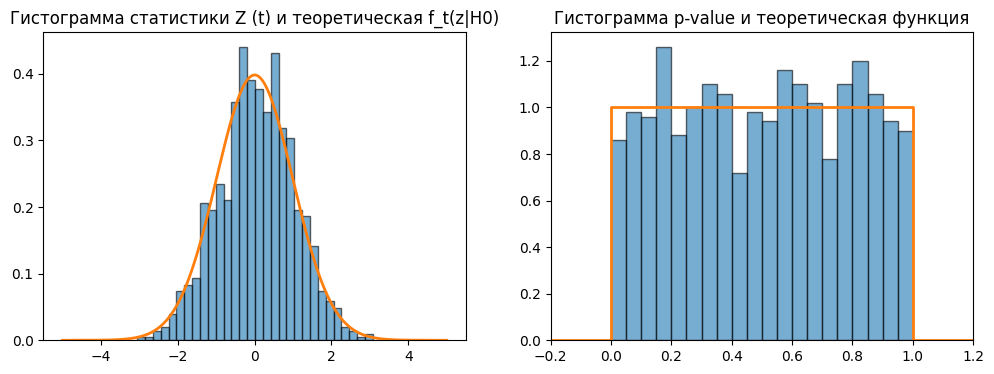

<Figure size 640x480 with 0 Axes>

In [6]:
m0 = 1
alpha = 0.05
N = 1000
nu = n1 - 1

theo_mean_Z = 0.0
theo_var_Z = nu / (nu - 2) if nu > 2 else np.inf
theo_std_Z = np.sqrt(theo_var_Z) if np.isfinite(theo_var_Z) else np.inf

theo_mean_p = 0.5
theo_var_p = 1/12
theo_std_p = np.sqrt(1/12)

theo_tbl = pd.DataFrame({
    "СВ": ["Z", "P-value"],
    "Распределение в условиях H0": [f"t(ν={nu})", "U(0,1)"],
    "Параметры": [f"ν={nu}", "a=0, b=1"],
    "Математическое ожидание": [theo_mean_Z, theo_mean_p],
    "Дисперсия": [theo_var_Z, theo_var_p],
    "С.к.о.": [theo_std_Z, theo_std_p],
})

t_stats = np.empty(N)
p_values = np.empty(N)

for i in range(N):
    sample = stats.norm.rvs(loc=m1_true, scale=sigma1_true, size=n1)
    t_stat, p_val = stats.ttest_1samp(sample, popmean=m0)
    t_stats[i] = t_stat
    p_values[i] = p_val

# --- Выборочные  характеристики
emp_tbl = pd.DataFrame({
    "СВ": ["Z", "P-value"],
    "Среднее": [np.mean(t_stats), np.mean(p_values)],
    "Оценка дисперсии": [np.var(t_stats, ddof=1), np.var(p_values, ddof=1)],
    "Оценка с.к.о.": [np.std(t_stats, ddof=1), np.std(p_values, ddof=1)],
})

print("Теоретические характеристики:")
display(theo_tbl)

print("\nВыборочные характеристики:")
display(emp_tbl)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(t_stats, bins=30, density=True, alpha=0.6, edgecolor="black")
x = np.linspace(-5, 5, 400)
axes[0].plot(x, stats.t.pdf(x, df=nu), lw=2, label=f"t-плотность (ν={nu})")
axes[0].set_title("Гистограмма статистики Z (t) и теоретическая f_t(z|H0)")

bins = np.linspace(0, 1, 21)
ax = plt.gca()
ax.hist(p_values, bins=bins, density=True, alpha=0.6, edgecolor="black", label="эмпирич.")

x_theor = [-0.2, -0.1, 0, 0, 1, 1, 1.1, 1.2]
y_theor = [0, 0, 0, 1, 1, 0, 0, 0]
ax.plot(x_theor, y_theor, linewidth=2, label="теор. U(0,1)")

ax.set_xlim(-0.2, 1.2)
ax.set_title("Гистограмма p-value и теоретическая функция")
plt.show()

plt.tight_layout()
plt.show()